In [1]:
import os
import cv2
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from detect_object_multiscale import detect_object_multiscale
import torch
from torchvision import transforms
from prototypical_net import ConvNet
from PIL import Image
import random

In [2]:
# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
patch_sizes = [84, 96, 112, 128]
stride = 20
class_list = ["apple", "kiwi", "carrot"]
workspace_dir = "images/workspace-images"
ground_truth_dir = "images/ground-truth-csv"
distance_threshold = 30

In [3]:
# --- Load model ---
model = ConvNet().to(device)
model.load_state_dict(torch.load("saved_models/prototypical_net_model.pth", map_location=device))
model.eval()

ConvNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1

In [4]:
# --- Define transform ---
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

all_true = []
all_pred = []

In [5]:
# --- Evaluate across images and classes ---
for img_file in os.listdir(workspace_dir):
    if not img_file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    image_path = os.path.join(workspace_dir, img_file)
    gt_csv_path = os.path.join(ground_truth_dir, os.path.splitext(img_file)[0] + ".csv")

    if not os.path.exists(gt_csv_path):
        print(f"[!] Ground truth missing for {img_file}, skipping.")
        continue

    workspace = cv2.imread(image_path)
    workspace = cv2.cvtColor(workspace, cv2.COLOR_BGR2RGB)
    gt_df = pd.read_csv(gt_csv_path)

    for class_name in class_list:
        support_dir = os.path.join("images/support-images-augmented", class_name)
        support_paths = [
            os.path.join(support_dir, f)
            for f in os.listdir(support_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        if len(support_paths) == 0:
            continue

        selected_paths = random.sample(support_paths, k=min(10, len(support_paths)))

        embeddings = []
        for path in selected_paths:
            img = Image.open(path).convert("RGB")
            tensor = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                emb = model(tensor)
                embeddings.append(emb)
        support_embedding = torch.mean(torch.stack(embeddings), dim=0)

        detected_list = detect_object_multiscale(
            model=model,
            support_path_list=selected_paths,
            workspace_path=image_path,
            patch_sizes=patch_sizes,
            stride=stride,
            device=device,
            distance=4
        )

        pred_points = [d['location'] for d in detected_list]
        gt_points = gt_df[gt_df['class'] == class_name][['x', 'y']].values.tolist()
        matched = set()

        for gx, gy in gt_points:
            found = False
            for i, (px, py) in enumerate(pred_points):
                if i in matched:
                    continue
                dist = np.sqrt((px - gx) ** 2 + (py - gy) ** 2)
                if dist < distance_threshold:
                    all_true.append(class_name)
                    all_pred.append(class_name)
                    matched.add(i)
                    found = True
                    break
            if not found:
                all_true.append(class_name)
                all_pred.append("none")

        for i in range(len(pred_points)):
            if i not in matched:
                all_true.append("none")
                all_pred.append(class_name)

In [6]:
# --- Final Report ---
print("\n=== Final Evaluation Across All Classes ===")
print(classification_report(all_true, all_pred, zero_division=0))


=== Final Evaluation Across All Classes ===
              precision    recall  f1-score   support

       apple       0.68      0.99      0.81       197
      carrot       0.07      0.76      0.12        71
        kiwi       0.46      1.00      0.63       232
        none       0.00      0.00      0.00      1107

    accuracy                           0.30      1607
   macro avg       0.30      0.69      0.39      1607
weighted avg       0.15      0.30      0.20      1607



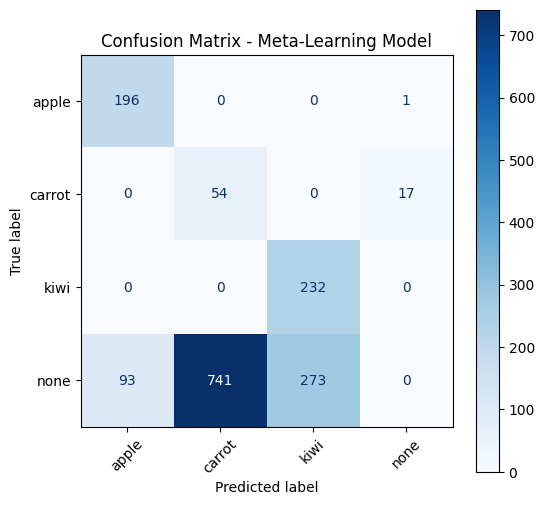

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
labels = sorted(set(all_true) | set(all_pred))  # all classes that appeared
cm = confusion_matrix(all_true, all_pred, labels=labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Meta-Learning Model") 
plt.show()